In [111]:
import os, json, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch
from torch.utils.data import DataLoader
from data_preprocess import load_and_prepare_data
from dataset import ValDataset, HOURS_IN_WEEK
from model import TimeSeriesTFM

In [ ]:
# -------- 1. 參數定義 --------
model_dir = "models/20250530_052344"   # 指定模型資料夾
STEP      = 6                          # 每幾小時取一筆樣本（1 = 不抽稀）

In [ ]:
# ---------------- 載入模型 & Scaler ----
with open(os.path.join(model_dir, "config.json")) as f:
    cfg = json.load(f)
with open(os.path.join(model_dir, "scaler.pkl"), "rb") as f:
    scaler = pickle.load(f)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TimeSeriesTFM(**{k:v for k,v in cfg.items() if k!="lr"}).to(DEVICE)
model.load_state_dict(torch.load(os.path.join(model_dir,"best.pt"), map_location=DEVICE))
model.eval()

print(f"DEVICE: {DEVICE}")

DEVICE: cuda


In [ ]:
# ---------------- 讀 2024 + 2025 原始資料 ----
raw_df = load_and_prepare_data(["Data/466920_2024.csv","Data/466920_2025.csv"])

# 自動決定評估區間：2025-01-01 ~ 最後一筆
start_date = raw_df.loc[raw_df["DateTime"].dt.year==2025, "DateTime"].min()
end_date   = raw_df["DateTime"].max() + pd.Timedelta(hours=1)

mask_eval  = (raw_df["DateTime"] >= start_date) & (raw_df["DateTime"] < end_date)
dt_eval    = raw_df.loc[mask_eval, "DateTime"].values
N_eval     = len(dt_eval)
print("評估範圍：", start_date, "~", end_date - pd.Timedelta(hours=1), "共", N_eval, "小時")

Evaluate hours: 3552


In [ ]:
# ---------------- 標準化給 Dataset ------------
work_df = raw_df.copy()
work_df[["Tx","RH","PrecpHour"]] = scaler.transform(work_df[["Tx","RH","PrecpHour"]])

def collate(b): xs,ys = zip(*b); return torch.tensor(xs), torch.tensor(ys)
valset = ValDataset(work_df, start_date=str(start_date), end_date=str(end_date))
loader = DataLoader(valset, batch_size=1, shuffle=False, collate_fn=collate)

# ---------------- 緩衝區 / 統計陣列 ------------
pred_sum = np.zeros((N_eval,3))
pred_cnt = np.zeros((N_eval,1))
true_buf = raw_df.loc[mask_eval, ["Tx","RH","PrecpHour"]].values

sqe  = np.zeros((3,168))
cntR = np.zeros((3,168))

In [ ]:
# ---------------- 逐步預測 ---------------------
with torch.no_grad():
    for k,(X,Y) in enumerate(loader):
        if k % STEP:                # 抽稀：只保留每 STEP 筆
            continue
        glb = valset.targets_idx[k]
        rel_start = np.where(mask_eval.values)[0].tolist().index(glb)
        rel_end   = min(rel_start+168, N_eval)

        X,Y = X.to(DEVICE), Y.to(DEVICE)
        out_std = model(X,Y).cpu().numpy()[0]
        out     = scaler.inverse_transform(out_std)
        true    = scaler.inverse_transform(Y.cpu().numpy()[0])

        out, true = out[:rel_end-rel_start], true[:rel_end-rel_start]

        # 時序：累加 + 次數
        pred_sum[rel_start:rel_end] += out
        pred_cnt[rel_start:rel_end] += 1

        # RMSE：全部 horizon 納入
        err2 = (out - true)**2
        h = err2.shape[0]
        sqe[:, :h]  += err2.T
        cntR[:, :h] += 1


In [ ]:
# -------- 平均預測 & RMSE ----------------------
avg_pred = pred_sum / np.where(pred_cnt==0,1,pred_cnt)
rmse = np.sqrt(sqe / cntR)

# -------- 文字摘要 ----------------------------
names = ["Tx (°C)","RH (%)","PrecpHour (mm)"]
summary = pd.DataFrame({
    "WeeklyAvg_RMSE" : rmse.mean(axis=1),
    "First24h_RMSE"  : rmse[:,:24].mean(axis=1),
    "Last24h_RMSE"   : rmse[:,-24:].mean(axis=1)
}, index=names).round(3)
display(summary)

,WeeklyAvg_RMSE,First24h_RMSE,Last24h_RMSE
Feature,,,
Tx (°C),0.092,0.081,0.102
RH (%),0.317,0.299,0.335
PrecpHour (mm),0.005,0.005,0.005


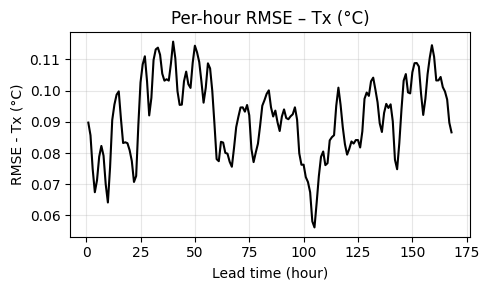

✅ models/20250530_052344\rmse_tx.png


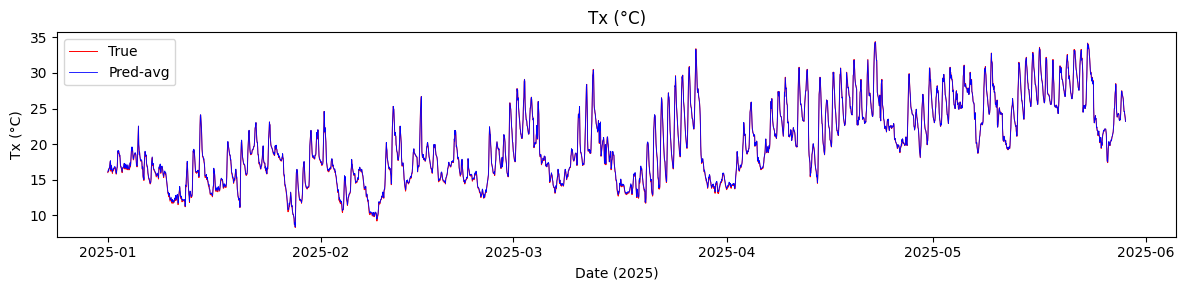

✅ models/20250530_052344\timeline_tx.png


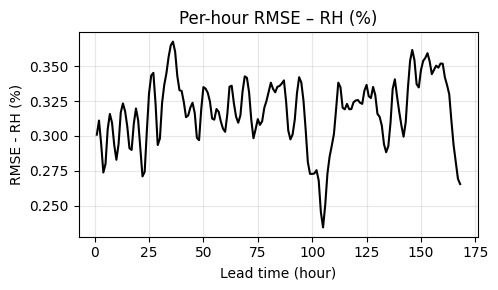

✅ models/20250530_052344\rmse_rh.png


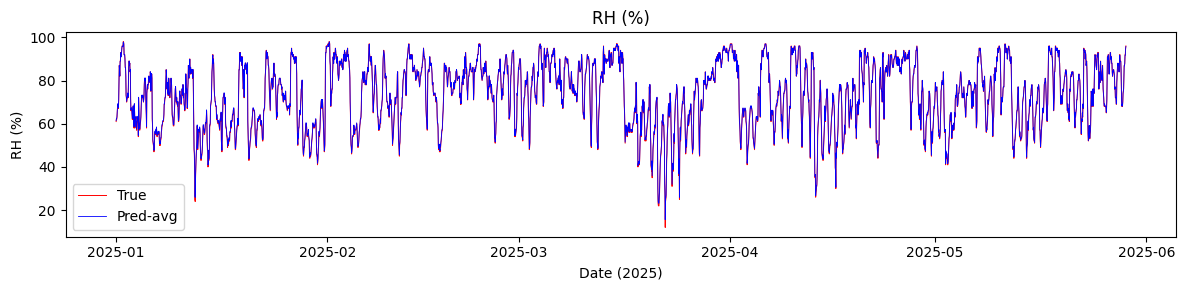

✅ models/20250530_052344\timeline_rh.png


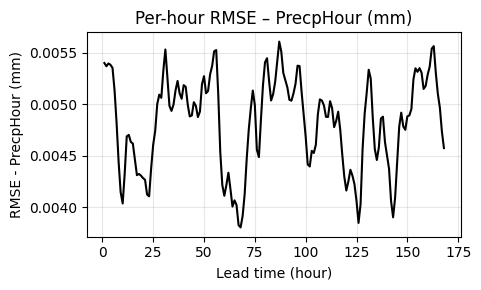

✅ models/20250530_052344\rmse_precp.png


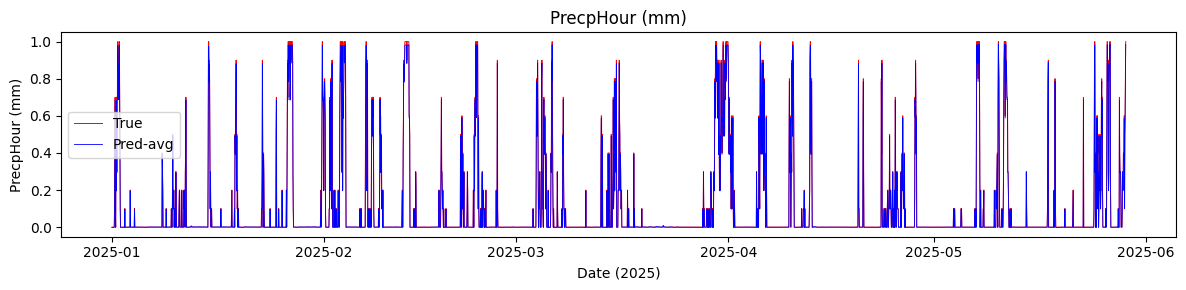

✅ models/20250530_052344\timeline_precp.png


In [ ]:
# -------- 繪 6 張圖 ---------------------------
rmse_png = ["rmse_tx.png","rmse_rh.png","rmse_precp.png"]
time_png = ["timeline_tx.png","timeline_rh.png","timeline_precp.png"]
hours = range(1,169)

for i in range(3):
    # (A) horizon RMSE
    plt.figure(figsize=(5,3))
    plt.plot(hours, rmse[i], color="black")
    plt.xlabel("Lead time (h)"); plt.ylabel(f"RMSE - {names[i]}")
    plt.title(f"Per-hour RMSE – {names[i]}"); plt.grid(alpha=.3); plt.tight_layout()
    p = os.path.join(model_dir, rmse_png[i]); plt.savefig(p); plt.show(); print("✓", p)

    # (B) 2025 時序：真值 vs. 平均預測
    plt.figure(figsize=(12,3))
    plt.plot(dt_eval, true_buf[:,i],  color="red",  label="True", linewidth=.7)
    plt.plot(dt_eval, avg_pred[:,i], color="blue", label="Pred-avg", linewidth=.6)
    plt.ylabel(names[i]); plt.xlabel("Date (2025)")
    plt.title(names[i]); plt.legend(); plt.tight_layout()
    p = os.path.join(model_dir, time_png[i]); plt.savefig(p); plt.show(); print("✓", p)